<a href="https://colab.research.google.com/github/Suharyanto-env/Sampah-Dumai/blob/main/IPS2_Peta%20IPS%20Dumai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [112]:
# =================================================================================
# PEMETAAN INDEKS PENGELOLAAN SAMPAH KOTA DUMAI
# =================================================================================

# 1. Install & import

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

In [113]:
# 2. Link google sheet format CSV

url = "https://docs.google.com/spreadsheets/d/16JlcSrmmUXqR5el5h5xvYEQ6zqQQlerMxSlVaMr4YnE/export?format=csv"
df = pd.read_csv(url)

In [140]:
# Rapikan format Data
df.columns = df.columns.str.strip()

# Pastikan kolom ada
print(df.columns)

# Format teks agar pasti match
df['Kecamatan'] = df['Kecamatan'].astype(str).str.strip().str.upper()

# ubah ke numeric (anti error tipe data)
cols = ["Timbulan","TPA SL","Terolah","Reduksi","TPA OD","%Kebocoran"]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

Index(['No', 'Kecamatan', 'Penduduk', 'Rasio', 'Timbulan', '%Pelayanan',
       'TPA SL', 'Sarpras PS', '%RT', 'RT', 'Terolah', 'Reduksi', 'TPA OD',
       'Leaked', 'Hidden', 'un_Manage', '%Kebocoran', 'K', 'S', 'IPS',
       'kategori_IPS', 'Terkelola', 'Unmanage'],
      dtype='object')


In [141]:
df['K'] = df['TPA SL'] + df['Sarpras PS'] + df['RT'] + df['Reduksi']
df['S'] = df['K'] + df['TPA OD'] + df['Leaked'] + df['Hidden']

df['IPS'] = ((df['K'] / df['S']) - 0.65) / 0.35

# handle pembagian nol
df.loc[df['S'] == 0, 'IPS'] = None

# clipping
df['IPS'] = df['IPS'].clip(-1, 1)

In [142]:
# Hitung Index Pengelolaan Sampah Kecamatan

def hitung_IPS(TPA_SL, Sarpras_PS, RT, Reduksi, TPA_OD, Leaked, Hidden):
    S = TPA_SL + Sarpras_PS + RT + Reduksi + TPA_OD + Leaked + Hidden
    K = TPA_SL + Sarpras_PS + RT + Reduksi

    if S == 0:
        return None  # setara "" di Excel

    IPS = ((K / S) - 0.65) / 0.35

    # pembatas -1 s/d 1
    IPS = max(-1, min(1, IPS))

    return IPS

In [143]:
print(df[['K','S']])

         K        S
0  14536.0  53600.0
1  29049.0  30940.0
2  30725.0  34300.0
3   4515.0  10150.0
4   8820.0  26600.0


In [144]:
# Klasifikasi IPS

def klasifikasi(x):
    if pd.isna(x):
        return "DATA KOSONG"
    elif -1 <= x <= -0.5:
        return "BURUK"
    elif -0.5 < x < -1e-6:
        return "KURANG"
    elif abs(x) <= 1e-6:
        return "CUKUP"
    elif 1e-6 < x <= 0.75:
        return "BAIK"
    elif 0.75 < x <= 1:
        return "SANGAT BAIK"
    else:
        return "DI LUAR RANGE"

In [122]:
df['kategori_IPS'] = df['IPS'].apply(klasifikasi)

PEMETAAN IPS Kecamatan

In [125]:
# Download GADM Indonesia (level kecamatan) -  PENTING SAAT BLM ADA FILE PETA
#url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_IDN_shp.zip"

#r = requests.get(url)
#with open("gadm.zip", "wb") as f:
 #   f.write(r.content)

# Extract
#with zipfile.ZipFile("gadm.zip", 'r') as zip_ref:
 #   zip_ref.extractall("gadm_data")

In [126]:
# 1. Upload SHP    CATATAN : klo sdh upload bisa di frezze dg "#" saja

#from google.colab import files     # CATATAN : Tanda # untuk lock code shg tidak minta upload data peta berulang
#files.upload()

In [146]:
# 2. Cek dahulu penamaan file peta spy saat proses merge df dan gdf, penamaan sdh sinkron

print(gdf.columns)
print(df.columns)

Index(['Kecamatan', 'kode_kecam', 'luas_wilay', 'geometry', 'IPS'], dtype='object')
Index(['No', 'Kecamatan', 'Penduduk', 'Rasio', 'Timbulan', '%Pelayanan',
       'TPA SL', 'Sarpras PS', '%RT', 'RT', 'Terolah', 'Reduksi', 'TPA OD',
       'Leaked', 'Hidden', 'un_Manage', '%Kebocoran', 'K', 'S', 'IPS',
       'kategori_IPS', 'Terkelola', 'Unmanage'],
      dtype='object')


In [147]:
# SINKRONISASI NAMA KOLOM

# Cek daftar
gdf = gpd.read_file("kecamatan_dumai.shp")
gdf = gdf.rename(columns={"nama_kecam":"Kecamatan"})   # Note: Index gdf tertulis 'nama_kecam'

# Rapikan format teks
gdf["Kecamatan"] = gdf["Kecamatan"].astype(str).str.lower().str.strip()
df["Kecamatan"] = df["Kecamatan"].astype(str).str.lower().str.strip()

In [148]:
# =========================
# HITUNG IPS
# =========================
df = df.fillna(0)

df['Terkelola'] = df['TPA SL'] + df['Sarpras PS'] + df['RT'] + df['Reduksi']
df['Unmanage']  = df['TPA OD'] + df['Leaked'] + df['Hidden']
df['S'] = df['Terkelola'] + df['Unmanage']

df['IPS'] = ((df['Terkelola'] / df['S']) - 0.65) / 0.35
df.loc[df['S'] == 0, 'IPS'] = None
df['IPS'] = df['IPS'].clip(-1, 1)

In [149]:
# hapus kolom IPS lama jika ada
gdf = gdf.drop(columns=['IPS'], errors='ignore')
gdf = gdf.drop(columns=['IPS_x','IPS_y'], errors='ignore')

In [151]:
# Merge  (setelah itung IPS)
gdf = gdf.merge(df[['Kecamatan','IPS']], on='Kecamatan', how='left')

In [150]:
print("Kolom gdf:", gdf.columns)
print("Kolom df:", df.columns)

Kolom gdf: Index(['Kecamatan', 'kode_kecam', 'luas_wilay', 'geometry'], dtype='object')
Kolom df: Index(['No', 'Kecamatan', 'Penduduk', 'Rasio', 'Timbulan', '%Pelayanan',
       'TPA SL', 'Sarpras PS', '%RT', 'RT', 'Terolah', 'Reduksi', 'TPA OD',
       'Leaked', 'Hidden', 'un_Manage', '%Kebocoran', 'K', 'S', 'IPS',
       'kategori_IPS', 'Terkelola', 'Unmanage'],
      dtype='object')


In [152]:
print(gdf[['Kecamatan','IPS']])

         Kecamatan       IPS
0      bukit kapur  0.702207
1      dumai barat  0.825376
2      dumai timur -1.000000
3    medang kampai -0.586207
4  sungai sembilan -0.909774


In [134]:
colors = [
    (-1, "#808080"),   # abu
    (-0.5, "#FF9999"), # merah muda
    (0, "#FFFF66"),    # kuning
    (0.5, "#66CCFF"),  # biru muda
    (1, "#00AA00")     # hijau
]

cmap = LinearSegmentedColormap.from_list(
    "ips_map",
    [( (v+1)/2 , c ) for v,c in colors]
)

norm = Normalize(vmin=-1, vmax=1)

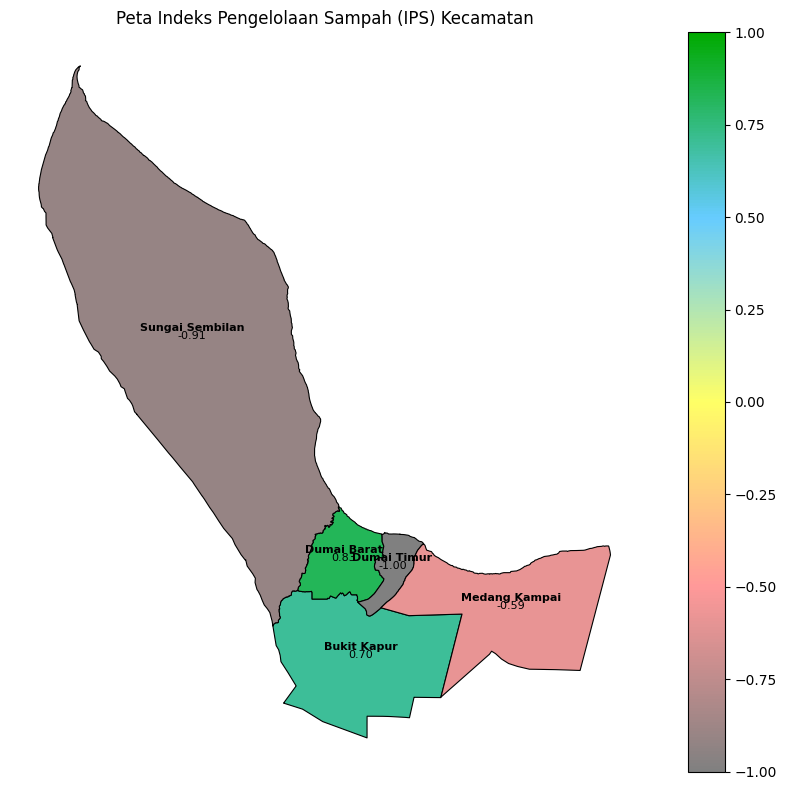

In [153]:
fig, ax = plt.subplots(1, 1, figsize=(10,8))

gdf.plot(
    column='IPS',
    cmap=cmap,
    norm=norm,
    linewidth=0.8,
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.set_title("Peta Indeks Pengelolaan Sampah (IPS) Kecamatan")
ax.axis('off')

# label angka IPS
for idx, row in gdf.iterrows():
    if row['geometry'] is not None and pd.notna(row['IPS']):
        x, y = row['geometry'].centroid.coords[0]
        ax.text(x, y, f"{row['IPS']:.2f}", ha='center', fontsize=8)

for idx, row in gdf.iterrows():
    if row['geometry'] is not None:
        x, y = row['geometry'].centroid.coords[0]
        ax.text(
            x, y + 0.01,                 # geser sedikit ke atas
            row['Kecamatan'].title(),    # nama kecamatan
            ha='center',
            fontsize=8,
            fontweight='bold',
            color='black'
        )

plt.tight_layout()
plt.show()


PENGANTAR PETA INDEKS PENGELOLAAN SAMPAH (IPS)
1. Pentingnya Peta IPS

Peta IPS digunakan untuk menampilkan perbedaan kinerja pengelolaan sampah antar kecamatan secara visual.
Dengan peta, wilayah yang sudah baik dan yang masih bermasalah dapat langsung teridentifikasi tanpa harus membaca tabel angka.

➡️ Peta menjadi alat utama untuk menentukan prioritas intervensi secara cepat dan tepat sasaran.

2. Definisi Singkat

Peta IPS adalah representasi spasial yang menggambarkan tingkat kinerja pengelolaan sampah di setiap kecamatan, berdasarkan proporsi sampah yang terkelola.

3. Manfaat Utama
Identifikasi cepat wilayah prioritas (kecamatan bermasalah)
Dasar pengambilan kebijakan berbasis data
Efisiensi alokasi anggaran dan program
Media komunikasi yang mudah dipahami oleh pimpinan dan masyarakat
Alat monitoring kinerja antar wilayah dan antar waktu

Klasifikasi Warna & Makna Strategis
🟢 HIJAU (IPS = 1) — OPTIMAL / IDEAL

Makna:

Hampir seluruh sampah terkelola
Sistem sudah matang (hulu–hilir berjalan)

Kebijakan:

Pertahankan (maintenance system)
Replikasi ke kecamatan lain (best practice)
Fokus ke:
Circular economy
Pengurangan dari sumber (zero waste)
🔵 BIRU MUDA (IPS ≈ 0.5) — MAJU / STABIL

Makna:

Sistem sudah kuat, tapi belum optimal
Layanan sudah menjangkau sebagian besar wilayah

Kebijakan:

Optimasi sistem (bukan bangun dari nol)
Tingkatkan efisiensi layanan
Fokus ke:
Perluasan cakupan layanan
Penguatan TPS3R/Bank Sampah
🟡 KUNING (IPS = 0) — AMBANG MINIMUM

Makna:

Baru memenuhi standar minimum (±65% terkelola)
Rentan turun jika tidak ditingkatkan

Kebijakan:

Intervensi penguatan sistem
Perlu percepatan program
Fokus ke:
Penambahan sarpras
Edukasi masyarakat
Penataan layanan
🔴 MERAH (IPS ≈ -0.5) — KRITIS

Makna:

Dominasi sampah tidak terkelola
Kebocoran tinggi (lingkungan mulai terancam)

Kebijakan:

Intervensi intensif (prioritas utama)
Kombinasi:
Infrastruktur dasar (layanan angkut, TPS)
Penegakan aturan
Pembinaan masyarakat

➡️ Ini zona “harus turun tangan langsung”

⚫ ABU-ABU (IPS = -1) — KOLAPS SISTEM

Makna:

Hampir tidak ada sistem pengelolaan
Sampah tidak terkelola secara luas

Kebijakan:

Penanganan darurat
Bangun sistem dari nol
Fokus ke:
Layanan dasar minimum
Intervensi pemerintah langsung
Program khusus (pilot project)

➡️ Ini zona “krisis lingkungan”